## On Policy Monte Carlo Control example of Maze

In [1]:
USE {
    repositories {
        mavenCentral()
        maven("https://central.sonatype.com/repository/maven-snapshots/")
    }
    dependencies {
        implementation("io.github.kotlinrl:envs:0.1.0-SNAPSHOT")
    }
}
%use dataframe
%use kandy

In [2]:
import io.github.kotlinrl.core.*
import io.github.kotlinrl.envs.*
import java.io.*

Let's define our hyper-parameters to control training and learning

In [3]:
val maxStepsPerEpisode = 1_0000
val trainingEpisodes = 1_000
val testEpisodes = 30
val initialEpsilon = 1.0
val epsilonDecayRate = 0.997
val minEpsilon = 0.05
val gamma = 0.99
val fileName = "MazeOnPolicyMonteCarloControl.csv"

Creating the following
- Maze = ```Env<IntArray, Int, MultiDiscrete, Discrete>```
- The ```QTable``` used to capture training information
    - Monte Carlo Control must wait until the end of each Episode to update the ```QTable```

In [4]:
val env = Maze(render = true)
val recordEnv = RecordVideo(env = env, folder = "videos/maze_on_policy_mcc", 10)
val trainingQtable = QTable(5, 5, 4)

Next we create the ```EpisodicTrainer``` using:
- the ```Maze``` env
- an ```onPolicyMonteCarloControlAgent```
    - We use an Epsilon Greedy Policy with a decaying epsilon
        - This policy needs ```StateActionListProvider``` to define the list of Actions for any State.
            - Actions
                - UP = 0
                - Right = 1
                - DOWN = 2
                - LEFT = 3
        - This policy also needs the ```QTable``` as its ```QFunction```
        - The policy randomly chooses a number.
            - If it is less than the epsilon value it uses a Random Policy selection
            - Otherwise it uses a Greedy Policy to select the best action from the ```QTable```
- We also register the episode logger
- We then train for the number of training episodes
- When training completes we save the ```QTable``` for later use

In [ ]:
val trainer = episodicTrainer(
    env = env,
    agent = onPolicyMonteCarloControlAgent(
        id = "training",
        policy = epsilonGreedyPolicy(
            stateActionListProvider = { listOf(0, 1, 2, 3) },
            epsilon = decayingParameterSchedule(
                initialValue = initialEpsilon,
                minValue = minEpsilon,
                decayRate = epsilonDecayRate
            ),
            qTable = trainingQtable
        ),
        gamma = gamma
    ),
    maxStepsPerEpisode = maxStepsPerEpisode,
    callbacks = listOf(
        printEpisodeStart(10)
    )
)
println("Starting training")
val training = trainer.train(trainingEpisodes)
trainingQtable.save(fileName)


Once training is complete, we create the following
- A new ```QTable``` with the same shape, and load the training data
- A new test ```Agent``` using a ```GreedyPolicy``` against the ```QTable``` with loaded weights
- The Greedy Policy always chooses the best action from the ```QTable```
    - It performs the best action given the state: ```(playerSum, dealerSum, usableAce)```

We then test for the number of testing episodes to compare the episode results (i.e. the average reward achieved)

In [6]:
val testingQtable = QTable(5, 5, 4)
testingQtable.load(fileName)

In [ ]:
val tester = episodicTrainer(
    env = recordEnv,
    agent = agent(
        id = "testing",
        policy = greedyPolicy(testingQtable)
    ),
    maxStepsPerEpisode = maxStepsPerEpisode,
    callbacks = listOf(
        printEpisodeStart(10)
    )
)
println("Starting testing")
val test = tester.train(testEpisodes)

Compare the average results.

In [ ]:
println("Training average reward: ${training.averageReward}")
println("Test average reward: ${test.averageReward}")
val folder = File(recordEnv.folder)
for(file in folder.listFiles()!!.filter { it.isDirectory }) {
    displayVideo(File(folder, file.name))
}

Let's plot our results

In [7]:
val format: String = "%6.2f"
val actionSymbols = mapOf(0 to "↑", 1 to "→", 2 to "↓", 3 to "←")
val shape = testingQtable.shape

val stateDf = buildList {
    for (row in 0 until shape[0]) {
        for (col in 0 until shape[1]) {
            val state = intArrayOf(row, col)
            val valueRaw = testingQtable.maxValue(state)
            val valueStr = format.format(valueRaw)
            val action = testingQtable.bestAction(state)
            val arrow = actionSymbols[action] ?: "?"

            // Two rows per cell: one for Value, one for Policy
            add(mapOf("x" to col, "y" to -row, "value" to valueRaw, "label" to valueStr, "type" to "Value"))
            add(mapOf("x" to col, "y" to -row, "value" to valueRaw, "label" to arrow, "type" to "Policy"))
        }
    }
}.flatMap { it.entries }.groupBy({ it.key}, { it.value }).toDataFrame()

plotGrid(stateDf.groupBy("type").map { (typeLabel, group) ->
    group.plot {
        layout.title = typeLabel[0]?.toString() ?: ""

        tiles {
            x("x")
            y("y")
            fillColor("value") {
                scale = continuous(Color.BLUE..Color.WHITE)
            }
            borderLine {
                width = 0.5
                color = Color.BLACK
            }
        }


        text {
            x("x")
            y("y")
            label("label")
            font {
                size = if (typeLabel[0] == "Policy") 18.0 else 6.0
                color = Color.BLACK
            }
        }

        x.axis.name = "x"
        y.axis.name = "y"
    }
})

<head>
 <meta charset="UTF-8">
 <style> html, body { margin: 0; overflow: hidden; } </style>
 <script type="text/javascript" data-lets-plot-script="library" src="https://cdn.jsdelivr.net/gh/JetBrains/lets-plot@v4.5.1/js-package/distr/lets-plot.min.js"></script>
 </head>
 <body>
 <div id="hkWCJk"></div>
 <script type="text/javascript" data-lets-plot-script="plot">
 
 (function() {
 // ----------
 
 var plotSpec={
"layout":{
"name":"grid",
"ncol":2,
"nrow":1,
"fit":true,
"align":false
},
"figures":[{
"ggtitle":{
"text":"Value"
},
"mapping":{
},
"data":{
"x":[0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0],
"y":[0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-2.0,-2.0,-2.0,-2.0,-2.0,-3.0,-3.0,-3.0,-3.0,-3.0,-4.0,-4.0,-4.0,-4.0,-4.0],
"label":["-25.55","-37.40","-94.54","-84.27","-87.08","-21.72","-56.60"," -1.00","-96.01","-100.00","-14.07","-56.25","-41.00","-95.40","-100.00","-13.48","-56.10"," -3.15"," -2.11"," -1.00","-12.08"," -8.92"," -4.36"," -1.00"," 0.00"],
"value":[-25.545835095906746,-37.39535687195368,-94.53820805705016,-84.27441545185793,-87.08025564474484,-21.716878213941577,-56.59796832635889,-1.0,-96.01368374335888,-99.99999839033497,-14.072235938534373,-56.252673206606985,-40.99737796890736,-95.39580472357963,-99.99999923886443,-13.479728065603483,-56.09506673106046,-3.153968355345489,-2.112933187398178,-1.0,-12.075758115178706,-8.918875188698383,-4.360361730678516,-1.0,0.0]
},
"kind":"plot",
"scales":[{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"fill",
"scale_mapper_kind":"color_gradient",
"high":"#ffffff",
"low":"#5470c6",
"limits":[null,null]
},{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"x",
"name":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"name":"y",
"limits":[null,null]
}],
"layers":[{
"mapping":{
"x":"x",
"y":"y",
"fill":"value"
},
"stat":"identity",
"size":0.5,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"tile",
"data":{
}
},{
"mapping":{
"x":"x",
"y":"y",
"label":"label"
},
"stat":"identity",
"size":6.0,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"text",
"data":{
}
}],
"data_meta":{
"series_annotations":[{
"type":"int",
"column":"x"
},{
"type":"int",
"column":"y"
},{
"type":"float",
"column":"value"
},{
"type":"str",
"column":"label"
}]
},
"spec_id":"3"
},{
"ggtitle":{
"text":"Policy"
},
"mapping":{
},
"data":{
"x":[0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0,0.0,1.0,2.0,3.0,4.0],
"y":[0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-2.0,-2.0,-2.0,-2.0,-2.0,-3.0,-3.0,-3.0,-3.0,-3.0,-4.0,-4.0,-4.0,-4.0,-4.0],
"label":["↓","←","→","↑","↑","↓","→","↑","↓","←","↓","↓","↑","↑","↓","↓","↑","→","↓","↓","→","→","↑","→","↑"],
"value":[-25.545835095906746,-37.39535687195368,-94.53820805705016,-84.27441545185793,-87.08025564474484,-21.716878213941577,-56.59796832635889,-1.0,-96.01368374335888,-99.99999839033497,-14.072235938534373,-56.252673206606985,-40.99737796890736,-95.39580472357963,-99.99999923886443,-13.479728065603483,-56.09506673106046,-3.153968355345489,-2.112933187398178,-1.0,-12.075758115178706,-8.918875188698383,-4.360361730678516,-1.0,0.0]
},
"kind":"plot",
"scales":[{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"fill",
"scale_mapper_kind":"color_gradient",
"high":"#ffffff",
"low":"#5470c6",
"limits":[null,null]
},{
"aesthetic":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"limits":[null,null]
},{
"aesthetic":"x",
"name":"x",
"limits":[null,null]
},{
"aesthetic":"y",
"name":"y",
"limits":[null,null]
}],
"layers":[{
"mapping":{
"x":"x",
"y":"y",
"fill":"value"
},
"stat":"identity",
"size":0.5,
"color":"#000000",
"sampling":"none",
"inherit_aes":false,
"position":"identity",
"geom":"tile",
"data":{
}
},{
"mapping":{
"x":"x",
"y":"y",
"label":"label"
},
"stat":"identity

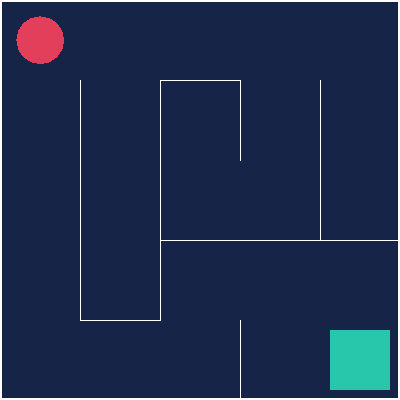

In [11]:
import java.io.File
import javax.imageio.ImageIO
import java.awt.image.BufferedImage

val pngFile = File(recordEnv.folder).listFiles()?.sorted()?.first()?.listFiles()?.sorted()?.first()

val image: BufferedImage = ImageIO.read(pngFile)
image